# RenAIssance Test II — handwritten VLM OCR
I run **Gemini 2.5 Flash** on full manuscript pages (PNG exports from the PDFs) with a paleography-style prompt. No line segmentation step: the model sees the whole page image after downscaling for the API.


### 0. Initialize environment
**Run this first.** It finds the repo root, adds `src` to the path, and imports the helpers used below.


In [1]:
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import json


def find_project_root() -> Path:
    """Resolve repo root whether the kernel cwd is the repo or notebooks/."""
    here = Path.cwd().resolve()
    for d in (here, *here.parents):
        if (d / "src" / "utils.py").is_file():
            return d
    raise RuntimeError(
        "Could not find repo root (no src/utils.py). Open the CNN-RNN folder in VS Code and try again."
    )


ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.utils import read_jsonl
from src.evaluate import evaluate_records, load_ground_truth_records

print(f"Initialization complete! Project root: {ROOT}")

Initialization complete! Project root: /Users/ray/CNN-RNN


### 1. A sample page image
PNGs and `manifest.jsonl` come from `scripts/extract_pages.py` (not re-run inside this notebook).


Viewing ahpg_gpah_1_1716_a_35_1744_page_0001...


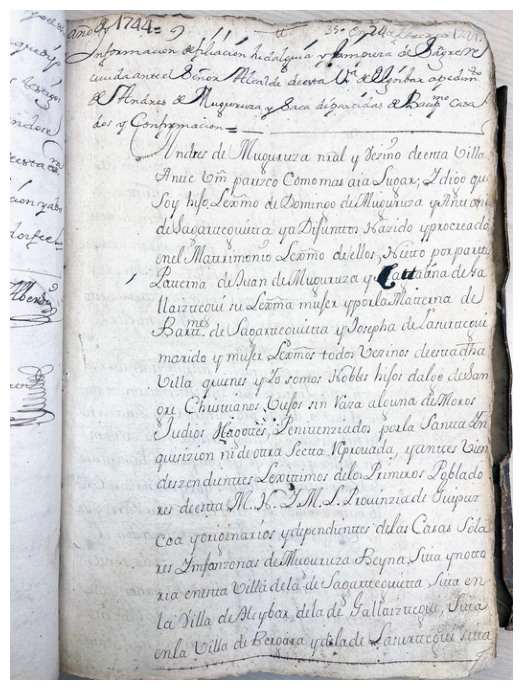

In [2]:
if "ROOT" not in globals(): raise RuntimeError("Please run the 'Initialize Environment' cell at the top first!")

from PIL import Image as PILImage
PILImage.MAX_IMAGE_PIXELS = None  # manuscript pages exceed default Pillow limit

manifest_path = ROOT / "data/page_images/manifest.jsonl"
manifest = read_jsonl(manifest_path)
sample_page = manifest[0]

print(f"Viewing {sample_page['page_id']}...")
img_path = ROOT / sample_page["image_path"]
# Thumbnail before display so notebook/PDF embed stays small (full PNGs are huge).
im = PILImage.open(img_path).convert("RGB")
im.thumbnail((700, 700), PILImage.Resampling.LANCZOS)
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(im)
ax.axis("off")
plt.tight_layout()
plt.show()

### 2. Predictions vs ground truth
Load VLM output and compare to `ground_truth.jsonl`. If `data/predictions/vlm_results_submission.jsonl` exists, that file is used (the snapshot I’m submitting); otherwise `vlm_results.jsonl`.


In [3]:
if "ROOT" not in globals():
    raise RuntimeError("Please run the 'Initialize Environment' cell at the top first!")

_pred = ROOT / "data/predictions/vlm_results_submission.jsonl"
if not _pred.is_file():
    _pred = ROOT / "data/predictions/vlm_results.jsonl"
preds = read_jsonl(_pred)
print(f"Predictions file: {_pred.name}")
for p in preds:
    if "vlm_text" in p:
        p["raw_ocr"] = p["vlm_text"]
        p["cleaned_ocr"] = p["vlm_text"]

if not preds:
    print("No VLM predictions found! Run 'python scripts/vlm_extract.py' in your terminal first.")
else:
    gt = load_ground_truth_records(ROOT / "data/ground_truth/ground_truth.jsonl")
    out = evaluate_records(preds, gt)
    summary = out["summary"]
    print(f"Evaluated pages: {summary['evaluated_pages']}")
    print(f"Average CER: {summary['avg_raw_cer']:.4f}")
    print(f"Average WER: {summary['avg_raw_wer']:.4f}")
    if summary["missing_ground_truth_page_ids"]:
        print(f"Skipped (no GT): {len(summary['missing_ground_truth_page_ids'])} pages")

    if out["comparisons"]:
        first = out["comparisons"][0]
        v_text = first["raw_ocr"]
        g_text = first["ground_truth"]
        cer = first["raw_cer"]
        print(f"\n--- Sample: {first['page_id']} ---")
        print(f"Gemini prediction (excerpt):\n{v_text[:400]}...\n")
        print(f"Ground truth (excerpt):\n{g_text[:400]}...\n")
        print(f"CER on this page: {cer:.2%}")

Predictions file: vlm_results_submission.jsonl


Evaluated pages: 5
Average CER: 0.1675
Average WER: 0.4019
Skipped (no GT): 10 pages

--- Sample: ahpg_gpah_1_1716_a_35_1744_page_0001 ---
Gemini prediction (excerpt):
año de 1744 = D
Informacion de filiacion hidalguia y
dada ante el Señor Alcalde de esta V. de
D. Andres de Muguuruza y Saca de Goribar apedimiento
dos y Confirmacion=
Andres de Muguuruza natural y Vezino de esta Villa
Anue o vn paunco Como mas aia Suor; Y dixo que
Soy hixo Legítimo de Domingo de Muguuruza y Antonia
de Saaxucouuia ya Difunto. Ha sido y procreado
en el Matrimonio Legítimo de ellos. ...

Ground truth (excerpt):
Informacion de filiacion hidalguia y limpieza de Sangre
unidad ante el Señor Alcalde de esta V.ª de Elgoibar a pedim.to
de Andres de Muguruza y Saca de partidas de Baup.mo casa-
dos y Confirmacion =
Andres de Muguruza n.al y Vezino de esta Villa
Ante Vm parezco como mas aya lugar; Y digo que
soy hijo Leg.mo de Domingo de Muguruza y Antonia
de Sagarzoguieta ya Difuntos Nacido y procreado
en el Matr...

## 3. Qualitative note
Mean CER on the five pages with references here is about **16.75%** (see the printout above). The model often expands abbreviations the ground truth keeps short, so the metric is harsher than how useful the text is. There are still plain mistakes on names and places.
